## k Nearest Neighbor
### Emmy Brown gsz5cv


In [186]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error,confusion_matrix, accuracy_score, classification_report

### Question 1

1. While both are methods to look at and make predictions, the main difference is that classification is meant to separate data into classes (categorical data), while regression is used to predict numbers (numeric data).  
2. A confusion table/matrix calculates the actual and predicted positives and negatives of a model, which is important so that we can understand where the model went wrong and what mistakes it made. It allows us to see in which classes it was accurate in predictions, and where it confused classes with one another.  
3. Accuracy is the proportion of predictions that the model got correct. It's not sufficient to evaluate a classifier's predictive performance because not all errors are of equal consequence and doesn't work well when classes are of very different size. 
4. The root mean squared error quantifies the size of the model's average prediction errors, showing that the higher the value, the less accurate the model, and the lower, the more accurate it is. 
5. Overfitting a model is when the training data fits the model to the point that it isn't applicable to many different sets, but instead just represents that data that you trained it on. Underfitting is when the model is too simple to capture the real patterns in the data.
6. Using training data allows us to create a model that will later allow us to see how data that was not used to fit the model is actually represented. We do this to prevent things such as overfitting the model, so we use the testing data to test how well the training data did at fitting the model. Choosing k is what allows us to balance the bias and variance of the model. 
7. A strength to reporting a class label as a prediction is that it is easy to understand and evaluate, making it easy to make decisions off of it. Its weakness is that it is hard when trying to make a risky decision that requires knowing the model's uncertainty. A strength in using it to label as probability distribution over class labels is that it captures the uncertainties and provides a flexible system that can be more easily manipulated without too much complexity. Its weaknesses are that it is more difficult to understand since it gives a less straightforward answer, and that it needs accurate calibrations and changes so that it can have the right thresholds to evaluate the data properly. 

### Question 2

In [187]:
# part 1

lmc = pd.read_csv('land_mines.csv')

print(lmc.isna().sum())
print('Shape:', lmc.shape)
print("Mine Type Counts:", lmc['mine_type'].value_counts())
lmc.head()

voltage      0
height       0
soil         0
mine_type    0
dtype: int64
Shape: (338, 4)
Mine Type Counts: mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [188]:
print(lmc[['voltage', 'height','soil']].describe())

          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000


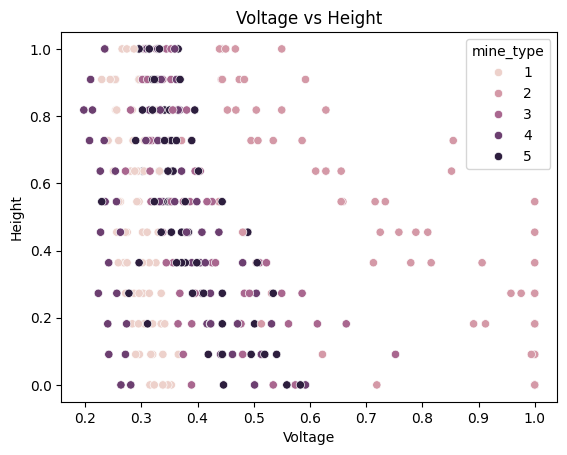

In [189]:
sns.scatterplot(lmc, x='voltage', y='height', hue='mine_type')
plt.xlabel("Voltage")
plt.ylabel("Height")
plt.title("Voltage vs Height")
plt.show()

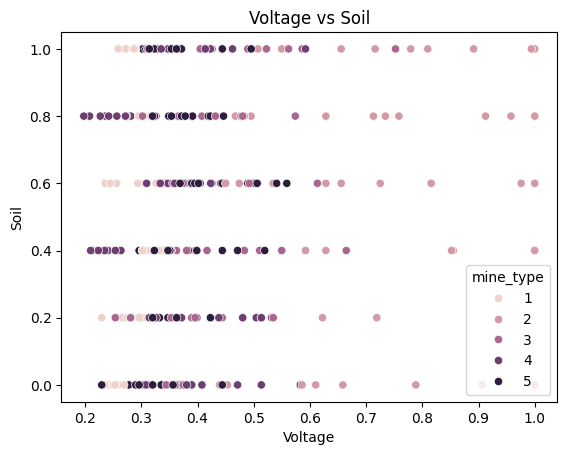

In [190]:
sns.scatterplot(lmc, x='voltage', y='soil', hue='mine_type')
plt.xlabel("Voltage")
plt.ylabel("Soil")
plt.title("Voltage vs Soil")
plt.show()

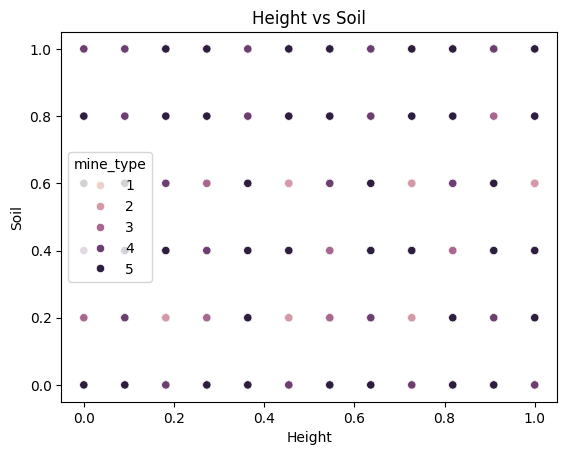

In [191]:
sns.scatterplot(lmc, x='height', y='soil', hue='mine_type')
plt.xlabel("Height")
plt.ylabel("Soil")
plt.title("Height vs Soil")
plt.show()

In [192]:
# part 2

x = lmc[['voltage', 'height', 'soil']]
y = lmc['mine_type']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.5, random_state=4, stratify=y)


In [193]:
# part 3

k_values = range(1,31)
acc_results = {}

for k in k_values:
    model = KNeighborsClassifier(n_neighbors = k) 
    model.fit(x_train,y_train) 

    pred = model.predict(x_test) 
    acc = accuracy_score(y_test, pred)
    acc_results[k] = acc

for k, acc in acc_results.items():
    print("ACC:", acc_results)

optimal_k = max(acc_results, key=acc_results.get)
print("Optimal K:", optimal_k)

ACC: {1: 0.3254437869822485, 2: 0.378698224852071, 3: 0.38461538461538464, 4: 0.378698224852071, 5: 0.3727810650887574, 6: 0.3668639053254438, 7: 0.3609467455621302, 8: 0.3668639053254438, 9: 0.3905325443786982, 10: 0.38461538461538464, 11: 0.3609467455621302, 12: 0.39644970414201186, 13: 0.3905325443786982, 14: 0.40828402366863903, 15: 0.3905325443786982, 16: 0.3668639053254438, 17: 0.3668639053254438, 18: 0.3609467455621302, 19: 0.38461538461538464, 20: 0.40828402366863903, 21: 0.40236686390532544, 22: 0.38461538461538464, 23: 0.40828402366863903, 24: 0.378698224852071, 25: 0.3668639053254438, 26: 0.3609467455621302, 27: 0.35502958579881655, 28: 0.3431952662721893, 29: 0.3668639053254438, 30: 0.34911242603550297}
ACC: {1: 0.3254437869822485, 2: 0.378698224852071, 3: 0.38461538461538464, 4: 0.378698224852071, 5: 0.3727810650887574, 6: 0.3668639053254438, 7: 0.3609467455621302, 8: 0.3668639053254438, 9: 0.3905325443786982, 10: 0.38461538461538464, 11: 0.3609467455621302, 12: 0.39644970

I chose to test k values 1 through 30 because I felt that it included what tended to be fairly optimal k values for this size data set. I ended up with 14 as the optimal value becuase it had the highest accuracy.

In [194]:
# part 4

opt_model = KNeighborsClassifier(n_neighbors=optimal_k)
opt_model.fit(x_train, y_train)

pred = opt_model.predict(x_test)

con_mat = confusion_matrix(y_test, pred)
print(con_mat)

print("Accuracy:", accuracy_score(y_test, pred))

[[25  0  7  4  0]
 [ 1 29  4  1  0]
 [13  2  9  3  6]
 [13  4  8  3  5]
 [ 8  3 10  8  3]]
Accuracy: 0.40828402366863903


It is not very accurate. Mine types 1 and 2 are predicted very well, while types 3, 4, and 5 are not being recognized well. Performance is best in types 1 and 2, which we can tell from their diagonals making up a great proportion of their actual totals, so the proportion that it got right is very high. On the other hand, we see type 3 start to struggle, as it has a higher value on its off-diagonal than its actual diagonal. This shows that it is not being recognized well. Types 4 and 5 are even worse, with only a small percentage of their values being correctly identified. 

part 5  

As we can see above, while some predictions were very accurate, such as types 1 and 2, others were extremely inaccurate. I think that the best way to use this tool is not to make a final analysis, but instead to look at predicted probabilities while assessing the model's accuracy. This could bring to light which classes the model might be confusing so that you can look further into the data and the issues presented, but you can also use it to get an estimate on what the predicted values might be for a data set alongside other tools. I think it can be helpful, but should not be a stand-alone tool to rely on. 

### Question 3

In [195]:
# part 1

df = pd.read_csv("USA_cars_datasets.csv")
df = df[['price', 'year', 'mileage']]

print("Missing Values:", df.isna().sum())
print("Shape:", df.shape)
df.head()

Missing Values: price      0
year       0
mileage    0
dtype: int64
Shape: (2499, 3)


,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


In [196]:
# part 2

x = df[['year', 'mileage']]
y = df['price']

scaler = MinMaxScaler()
x_scale = scaler.fit_transform(x)

print(x.shape)
print(x_scale.shape)
print(y.shape)


(2499, 2)
(2499, 2)
(2499,)


In [197]:
# part 3

x_train, x_test, y_train, y_test = train_test_split(x_scale, y, test_size = 0.2, random_state= 11)

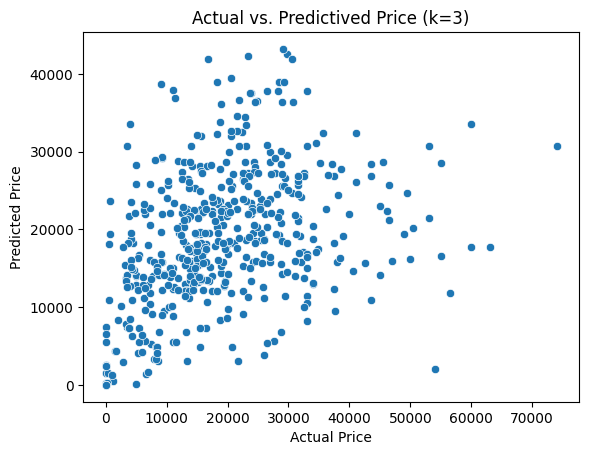

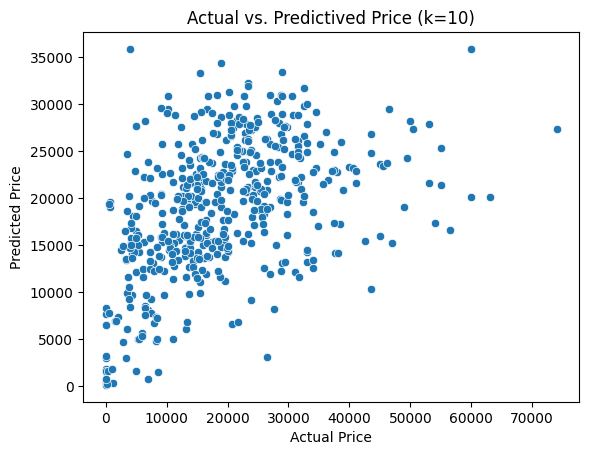

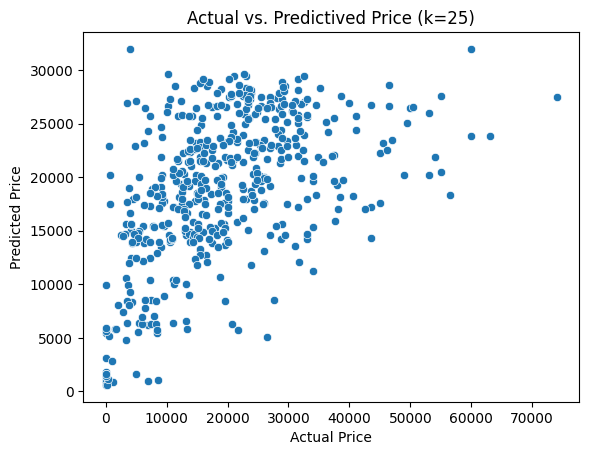

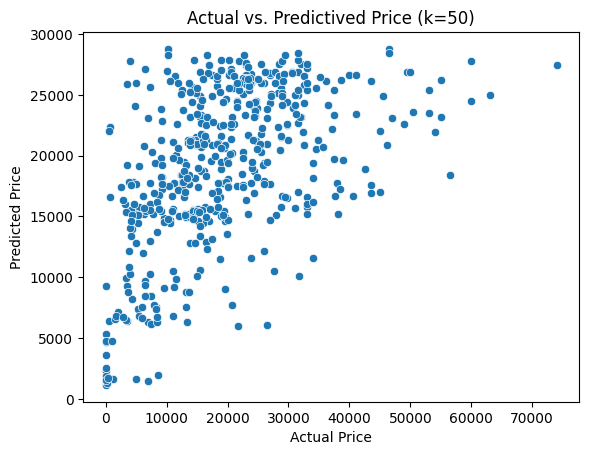

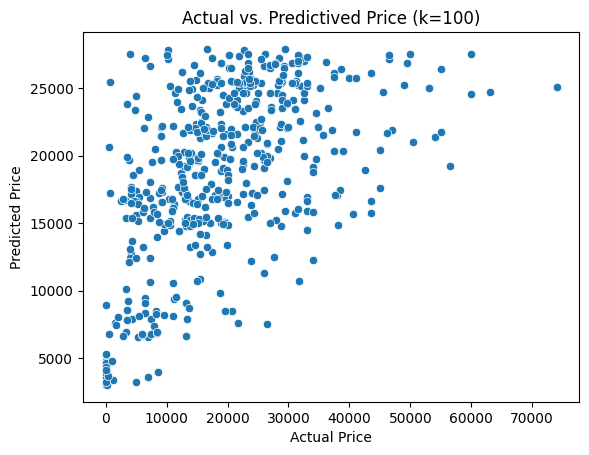

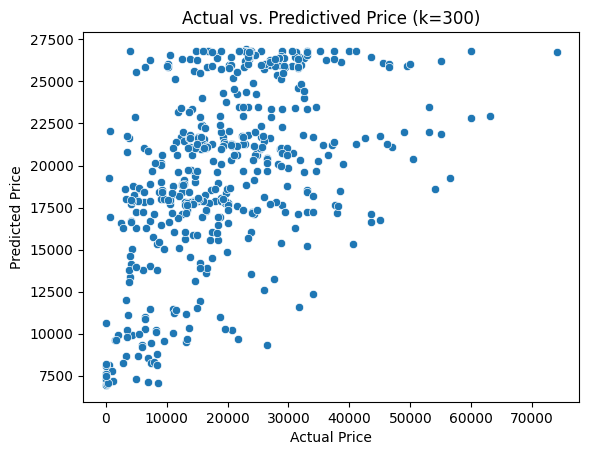

MSE: {3: 145313205.29355553, 10: 116321494.73674, 25: 109025496.1141248, 50: 106777285.2390888, 100: 107006985.48735781, 300: 109707368.23748899}


In [198]:
# part 4

# use knn and train to predict price with year and mileage
# for each k, compute mean squared error and scatterplot w/ test against predicted
k_values = [3, 10, 25, 50, 100, 300]
mse_results = {}

for k in k_values:
    model = KNeighborsRegressor(n_neighbors = k) 
    model.fit(x_train,y_train) 

    pred = model.predict(x_test) 
    mse = mean_squared_error(y_test, pred)
    mse_results[k] = mse

    sns.scatterplot(x=y_test, y=pred)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"Actual vs. Predictived Price (k={k})" )
    plt.show()

print("MSE:", mse_results)


In [199]:
# part 5

opt_k = min(mse_results, key=mse_results.get)
print('Optimal K:', opt_k)

Optimal K: 50


part 6  

What patterns do you notice?

When the k was 3, at its lowest, the mean squared error was the highest. The data points were very scattered and there was no general idea of what it was telling us. This was an example of overfitting, as it had a high variance. The data seemed to show more of a pattern and less variance as it approached k=50, with it reaching its lowest mean squared error at that value. The points had a more noticeable and distinct shape. As they k values increased again, there was a bit of change, but not as drastic as before. The model started to underfit the data, as it seemed less distracted by noise, but still was not very accurate in its shape.

### Question 4

In [200]:
# part 1

hf = pd. read_csv('heart_failure_clinical_records_dataset.csv')

print(hf.isna().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [201]:
hf = hf.drop('time', axis=1)
hf.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1


In [202]:
# part 2

hf.corr()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
age,1.000000,0.088006,-0.081584,-0.101012,0.060098,0.093289,-0.052354,0.159187,-0.045966,0.065430,0.018668,0.253729
anaemia,0.088006,1.000000,-0.190741,-0.012729,0.031557,0.038182,-0.043786,0.052174,0.041882,-0.094769,-0.107290,0.066270
creatinine_phosphokinase,-0.081584,-0.190741,1.000000,-0.009639,-0.044080,-0.070590,0.024463,-0.016408,0.059550,0.079791,0.002421,0.062728
diabetes,-0.101012,-0.012729,-0.009639,1.000000,-0.004850,-0.012732,0.092193,-0.046975,-0.089551,-0.157730,-0.147173,-0.001943
ejection_fraction,0.060098,0.031557,-0.044080,-0.004850,1.000000,0.024445,0.072177,-0.011302,0.175902,-0.148386,-0.067315,-0.268603
high_blood_pressure,0.093289,0.038182,-0.070590,-0.012732,0.024445,1.000000,0.049963,-0.004935,0.037109,-0.104615,-0.055711,0.079351
platelets,-0.052354,-0.043786,0.024463,0.092193,0.072177,0.049963,1.000000,-0.041198,0.062125,-0.125120,0.028234,-0.049139
serum_creatinine,0.159187,0.052174,-0.016408,-0.046975,-0.011302,-0.004935,-0.041198,1.000000,-0.189095,0.006970,-0.027414,0.294278
serum_sodium,-0.045966,0.041882,0.059550,-0.089551,0.175902,0.037109,0.062125,-0.189095,1.000000,-0.027566,0.004813,-0.195204
sex,0.065430,-0.094769,0.079791,-0.157730,-0.148386,-0.104615,-0.125120,0.006970,-0.027566,1.000000,0.445892,-0.004316


The variables serum_creatinine, ejection_fraction, serum_sodium, and age are the most strongly associated with death event.

In [203]:
# part 3 

hf.groupby('anaemia')['DEATH_EVENT'].describe()

,count,mean,std,min,25%,50%,75%,max
anaemia,,,,,,,,
0,170.0,0.294118,0.456991,0.0,0.0,0.0,1.0,1.0
1,129.0,0.356589,0.480859,0.0,0.0,0.0,1.0,1.0


In [204]:
hf.groupby('diabetes')['DEATH_EVENT'].describe()

,count,mean,std,min,25%,50%,75%,max
diabetes,,,,,,,,
0,174.0,0.321839,0.468530,0.0,0.0,0.0,1.0,1.0
1,125.0,0.320000,0.468353,0.0,0.0,0.0,1.0,1.0


In [205]:
hf.groupby('high_blood_pressure')['DEATH_EVENT'].describe()

,count,mean,std,min,25%,50%,75%,max
high_blood_pressure,,,,,,,,
0,194.0,0.293814,0.456687,0.0,0.0,0.0,1.0,1.0
1,105.0,0.371429,0.485504,0.0,0.0,0.0,1.0,1.0


In [206]:
hf.groupby('sex')['DEATH_EVENT'].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
0,105.0,0.323810,0.470173,0.0,0.0,0.0,1.0,1.0
1,194.0,0.319588,0.467523,0.0,0.0,0.0,1.0,1.0


In [207]:
hf.groupby('smoking')['DEATH_EVENT'].describe()

,count,mean,std,min,25%,50%,75%,max
smoking,,,,,,,,
0,203.0,0.325123,0.469579,0.0,0.0,0.0,1.0,1.0
1,96.0,0.312500,0.465946,0.0,0.0,0.0,1.0,1.0


The variables anaemia and high_blood_pressure have a higher proportion of the population die when the variable takes the value of 1 rather than 0.

In [208]:
# part 4

X = hf[['anaemia', 'high_blood_pressure', 'serum_creatinine', 'ejection_fraction', 'serum_sodium', 'age']]
Y = hf['DEATH_EVENT']

X.head()

,anaemia,high_blood_pressure,serum_creatinine,ejection_fraction,serum_sodium,age
0,0,1,1.9,20,130,75.0
1,0,0,1.1,38,136,55.0
2,0,0,1.3,20,129,65.0
3,1,0,1.9,20,137,50.0
4,1,0,2.7,20,116,65.0


In [209]:
# part 5

scaler = MinMaxScaler()

X_scale = scaler.fit_transform(X)

X_scale

array([[0.        , 1.        , 0.15730337, 0.09090909, 0.48571429,
        0.63636364],
       [0.        , 0.        , 0.06741573, 0.36363636, 0.65714286,
        0.27272727],
       [0.        , 0.        , 0.08988764, 0.09090909, 0.45714286,
        0.45454545],
       ...,
       [0.        , 0.        , 0.03370787, 0.6969697 , 0.71428571,
        0.09090909],
       [0.        , 0.        , 0.1011236 , 0.36363636, 0.77142857,
        0.09090909],
       [0.        , 0.        , 0.12359551, 0.46969697, 0.65714286,
        0.18181818]], shape=(299, 6))

In [210]:
# part 6

X_train, X_test, Y_train, Y_test = train_test_split(X_scale, Y, test_size = 0.2, random_state= 7)

In [211]:
# part 7 

k_values = range(1,31)
rmse_results_1 = {}

for k in k_values:
    model = KNeighborsRegressor(n_neighbors = k) 
    model.fit(X_train,Y_train) 

    pred = model.predict(X_test) 
    rmse = np.sqrt(mean_squared_error(Y_test, pred))
    rmse_results_1[k] = rmse

opt_k_1 = min(rmse_results_1, key = rmse_results_1.get)
print('Best K w/ Few Predictors:', opt_k_1)
print('Best RMSE:', rmse_results_1[opt_k_1])

Best K w/ Few Predictors: 10
Best RMSE: 0.36239941133138354


In [212]:
# part 8

X_full = hf.drop('DEATH_EVENT', axis=1)

scaler = MinMaxScaler()

X_scale_2 = scaler.fit_transform(X_full)

X_train_2, X_test_2, Y_train, Y_test = train_test_split(X_scale_2, Y, test_size = 0.2, random_state= 7)

k_values = range(1,31)
rmse_results_2 = {}

for k in k_values:
    model = KNeighborsRegressor(n_neighbors = k) 
    model.fit(X_train_2,Y_train) 

    pred = model.predict(X_test_2) 
    rmse = np.sqrt(mean_squared_error(Y_test, pred))
    rmse_results_2[k] = rmse

opt_k_2 = min(rmse_results_2, key = rmse_results_2.get)
print('Best K w/ Few Predictors:', opt_k_2)
print('Best RMSE:', rmse_results_2[opt_k_2])

Best K w/ Few Predictors: 30
Best RMSE: 0.40480905420996993


The model with the selected variables the first time has a better Mean Squared Error. I would prefer the first because it used the most important predictors, eliminating a lot of the noise and some of the error while still giving us the information we needed and found important. The RMSE increases as we add more variables, which we have seen is not always better because the error increases and becomes noisier.